In [34]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv; load_dotenv()
import os
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [35]:
llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    huggingfacehub_api_token=os.getenv('HF_TOKEN')
)
model = ChatHuggingFace(llm=llm)

In [36]:
class SentimentSchema(BaseModel):

    feedback: Literal['positive', 'negative'] = Field(description='Classify the following review into positive or negative')

structured_model = model.with_structured_output(SentimentSchema, method='json_schema')

In [37]:
class SentimentState(TypedDict):

    review: str
    sentiment: str
    diagnosis: str
    negative_response: str
    positive_response: str

In [38]:
graph = StateGraph(SentimentState)

In [39]:
def get_sentiment(state: SentimentState):

    prompt = f"Decide whether the review is positive or negative: {state['review']}"
    result = structured_model.invoke(prompt)
    
    return{'sentiment': result}

def get_diagnosis(state: SentimentState):

    prompt = f"Diagnose the negative review: {state['review']}"
    result = model.invoke(prompt)
    
    return{'sentiment': result.content}

def get_negative_response(state: SentimentState):

    prompt = f"Respond to the negative review {state['review']} according to the diagnosis {state['diagnosis']}"
    result = model.invoke(prompt)
    
    return{'negative_response': result.content}

def get_positive_response(state: SentimentState):

    prompt = f"Respond to the positive review: {state['review']}"
    result = model.invoke(prompt)
    
    return{'positive_response': result.content}

In [40]:
graph.add_node('get_sentiment', get_sentiment)
graph.add_node('get_diagnosis', get_diagnosis)
graph.add_node('get_negative_response', get_negative_response)
graph.add_node('get_positive_response', get_positive_response)

In [41]:
def reponse_branch(state: SentimentState) -> Literal['get_diagnosis', 'get_positive_response']:

    if state['sentiment'] == 'positive':
        return 'get_positive_response'
    else:
        return 'get_negative_response'

In [42]:
graph.add_edge(START, 'get_sentiment')
graph.add_conditional_edges('get_sentiment', reponse_branch)
graph.add_edge('get_diagnosis', 'get_negative_response')
graph.add_edge('get_negative_response', END)
graph.add_edge('get_positive_response', END)

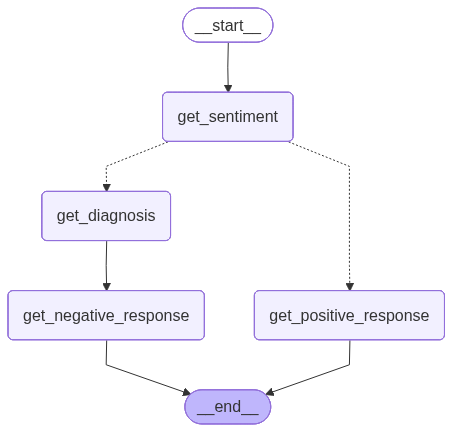

In [43]:
workflow = graph.compile()
workflow

In [ ]:
initial_state = {'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."}
workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help You with the Bug Issue

Hi [User's Name],

Thank you for reaching out and bringing this issue to our attention. I understand how frustrating it can be to deal with a bug, especially when it feels urgent. I'm here to help you resolve this as quickly as possible.

Could you please provide me with some additional details about the bug you’re experiencing? Specifically, it would be helpful to know:

1. A brief description of the issue.
2. The steps you took leading up to the bug.
3. Any error messages you might have seen.

Once I have this information, I’ll do my best to get you a solution or workaround pr